In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D,
    concatenate
)

from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
print("imports complete")

2026-06-27 01:13:08.280559: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782522788.539388      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782522788.605518      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782522789.230639      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782522789.230680      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782522789.230682      24 computation_placer.cc:177] computation placer alr

imports complete


In [2]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [3]:


DATASET_PATH = "/kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"

images = []
labels = []

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

classes = {
    "benign":0,
    "malignant":1
}

for folder, label in classes.items():

    folder_path = os.path.join(DATASET_PATH, folder)

    image_files = sorted([
        f for f in os.listdir(folder_path)
        if f.endswith(".png") and "_mask" not in f
    ])

    for image_name in image_files:

        image_path = os.path.join(folder_path,image_name)

        img = cv2.imread(image_path,cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img,(256,256))

        img = cv2.medianBlur(img,3)

        img = clahe.apply(img)

        img = img.astype(np.float32)/255.0

        images.append(img)

        labels.append(label)

X = np.array(images).reshape(-1,256,256,1)
y = np.array(labels)

print(X.shape)
print(y.shape)

(647, 256, 256, 1)
(647,)


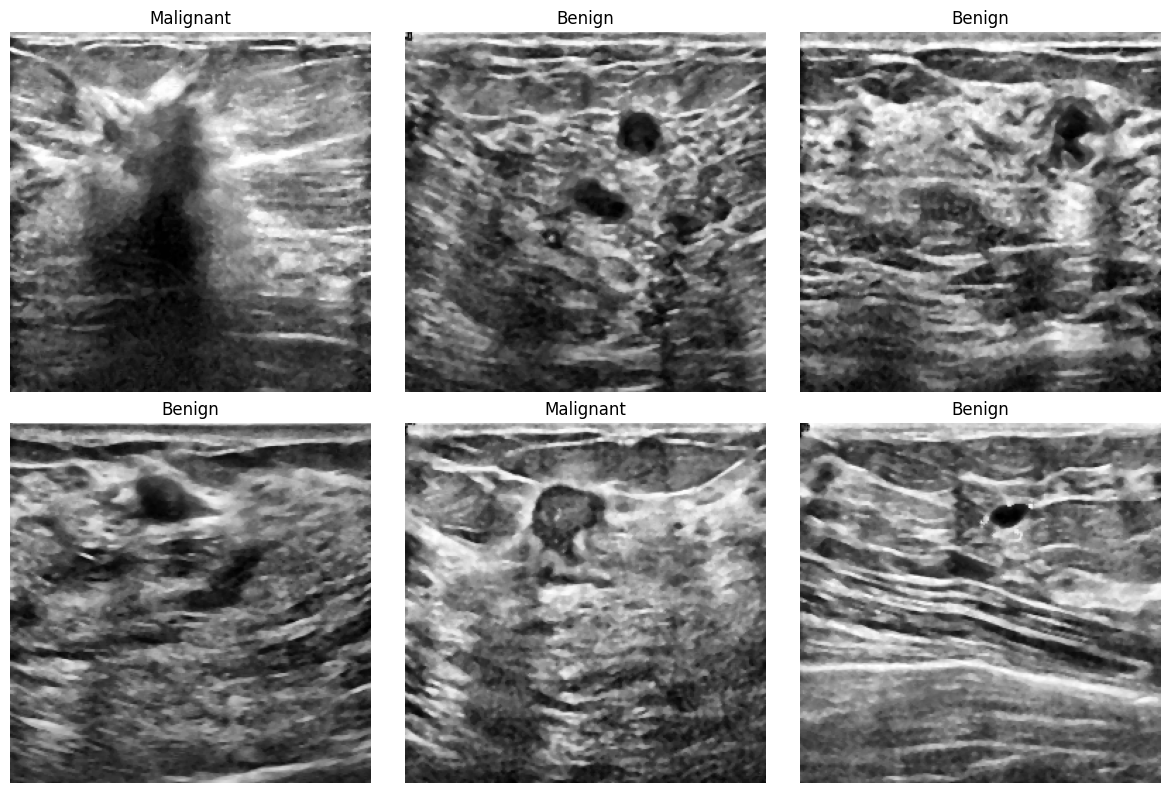

In [4]:
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(12,8))

# Pick 6 random images
indices = random.sample(range(len(X)), 6)

for i, idx in enumerate(indices):

    plt.subplot(2,3,i+1)

    plt.imshow(X[idx].squeeze(), cmap="gray")

    label = "Benign" if y[idx] == 0 else "Malignant"

    plt.title(label)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
import tensorflow as tf

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

valid_datagen = tf.keras.preprocessing.image.ImageDataGenerator()

train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=16
)

validation_generator = valid_datagen.flow(
    X_test,
    y_test,
    batch_size=16,
    shuffle=False
)

In [7]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

inputs = Input(shape=(256,256,3))

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_tensor=inputs
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.4)(x)

outputs = Dense(
    1,
    activation="sigmoid"
)(x)

resnet_model = Model(inputs, outputs)

resnet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

resnet_model.summary()

I0000 00:00:1782522822.833598      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782522822.839797      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [8]:
X_train_rgb = np.repeat(X_train,3,axis=-1)

X_test_rgb = np.repeat(X_test,3,axis=-1)

In [9]:
history_resnet = resnet_model.fit(

    X_train_rgb,

    y_train,

    validation_data=(X_test_rgb,y_test),

    epochs=20,

    batch_size=16

)

Epoch 1/20


I0000 00:00:1782522833.330417      76 service.cc:152] XLA service 0x7ecfa8012390 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782522833.330470      76 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782522833.330476      76 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782522835.123305      76 cuda_dnn.cc:529] Loaded cuDNN version 91002


 3/33 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.4410 - loss: 0.8030 

I0000 00:00:1782522839.375416      76 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


33/33 ━━━━━━━━━━━━━━━━━━━━ 24s 393ms/step - accuracy: 0.6093 - loss: 0.6805 - val_accuracy: 0.6769 - val_loss: 0.6138
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.6499 - loss: 0.6654 - val_accuracy: 0.6769 - val_loss: 0.6191
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.6673 - loss: 0.6212 - val_accuracy: 0.6769 - val_loss: 0.5921
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.6692 - loss: 0.6184 - val_accuracy: 0.7000 - val_loss: 0.5869
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.6673 - loss: 0.6027 - val_accuracy: 0.6769 - val_loss: 0.5738
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.6847 - loss: 0.5839 - val_accuracy: 0.6769 - val_loss: 0.5777
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.6983 - loss: 0.5944 - val_accuracy: 0.6769 - val_loss: 0.5650
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.7002 - loss: 0.5926 - val_accuracy: 0.8000 - val_loss: 

In [10]:
from tensorflow.keras.applications import EfficientNetB0

inputs = Input(shape=(256,256,3))

base_model = EfficientNetB0(

    weights="imagenet",

    include_top=False,

    input_tensor=inputs

)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.4)(x)

outputs = Dense(

    1,

    activation="sigmoid"

)(x)

efficient_model = Model(inputs,outputs)

efficient_model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

efficient_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 256, 256,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 256, 256,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 256, 256,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 257, 257,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 128, 128,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 128, 128,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 128, 128,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 128, 128,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 128, 128,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 128, 128,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 128, 128,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 128, 128,  │        512 │ block1a_se_excit

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [11]:
history_eff = efficient_model.fit(

    X_train_rgb,

    y_train,

    validation_data=(X_test_rgb,y_test),

    epochs=20,

    batch_size=16

)

Epoch 1/20


2026-06-27 01:15:11.569775: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-27 01:15:11.709695: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-27 01:15:12.027049: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-27 01:15:12.167254: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-27 01:15:12.962973: E external/local_xla/xla/stream_

32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6015 - loss: 0.6561

2026-06-27 01:15:26.806685: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-27 01:15:26.941363: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-27 01:15:27.253230: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-27 01:15:27.393388: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-27 01:15:28.149385: E external/local_xla/xla/stream_

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.6031 - loss: 0.6558

2026-06-27 01:15:46.464323: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-27 01:15:46.597381: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-27 01:15:46.902647: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-27 01:15:47.042124: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-27 01:15:47.186811: E external/local_xla/xla/stream_

33/33 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.6557 - loss: 0.6434 - val_accuracy: 0.6769 - val_loss: 0.6293
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6750 - loss: 0.6409 - val_accuracy: 0.6769 - val_loss: 0.6293
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6750 - loss: 0.6370 - val_accuracy: 0.6769 - val_loss: 0.6379
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6750 - loss: 0.6439 - val_accuracy: 0.6769 - val_loss: 0.6287
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6770 - loss: 0.6331 - val_accuracy: 0.6769 - val_loss: 0.6320
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6770 - loss: 0.6371 - val_accuracy: 0.6769 - val_loss: 0.6291
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6731 - loss: 0.6359 - val_accuracy: 0.6769 - val_loss: 0.6325
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6770 - loss: 0.6337 - val_accuracy: 0.6769 - val_loss: 0.6

In [12]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

pred_resnet = (resnet_model.predict(X_test_rgb)>0.5).astype(int)

pred_eff = (efficient_model.predict(X_test_rgb)>0.5).astype(int)

print("ResNet")

print("Accuracy :",accuracy_score(y_test,pred_resnet))

print("Precision :",precision_score(y_test,pred_resnet))

print("Recall :",recall_score(y_test,pred_resnet))

print("F1 :",f1_score(y_test,pred_resnet))

print()

print("EfficientNet")

print("Accuracy :",accuracy_score(y_test,pred_eff))

print("Precision :",precision_score(y_test,pred_eff))

print("Recall :",recall_score(y_test,pred_eff))

print("F1 :",f1_score(y_test,pred_eff))

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 930ms/step


2026-06-27 01:16:31.538735: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-27 01:16:31.684068: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-27 01:16:32.038351: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-27 01:16:32.179087: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-27 01:16:32.961348: E external/local_xla/xla/stream_

5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step
ResNet
Accuracy : 0.7769230769230769
Precision : 0.8823529411764706
Recall : 0.35714285714285715
F1 : 0.5084745762711864

EfficientNet
Accuracy : 0.676923076923077
Precision : 0.0
Recall : 0.0
F1 : 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


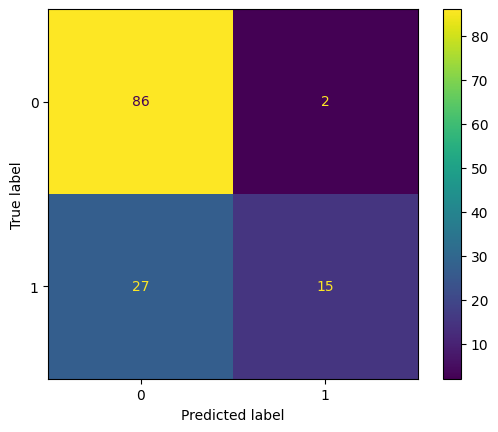

In [13]:
#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test,pred_resnet)

ConfusionMatrixDisplay(cm).plot()

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


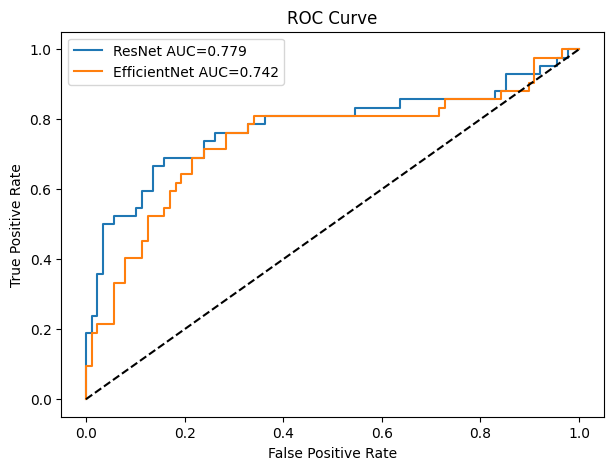

In [14]:
#roc curve
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

prob_resnet = resnet_model.predict(X_test_rgb)

prob_eff = efficient_model.predict(X_test_rgb)

fpr1,tpr1,_ = roc_curve(y_test,prob_resnet)

fpr2,tpr2,_ = roc_curve(y_test,prob_eff)

auc1 = auc(fpr1,tpr1)

auc2 = auc(fpr2,tpr2)

plt.figure(figsize=(7,5))

plt.plot(fpr1,tpr1,label=f"ResNet AUC={auc1:.3f}")

plt.plot(fpr2,tpr2,label=f"EfficientNet AUC={auc2:.3f}")

plt.plot([0,1],[0,1],'k--')

plt.legend()

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

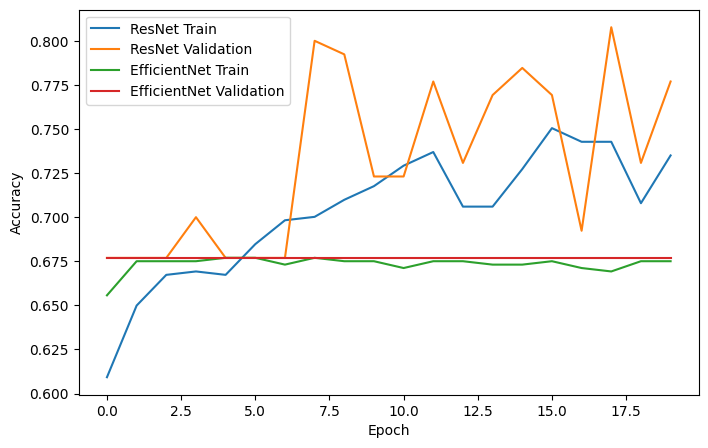

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history_resnet.history["accuracy"],label="ResNet Train")

plt.plot(history_resnet.history["val_accuracy"],label="ResNet Validation")

plt.plot(history_eff.history["accuracy"],label="EfficientNet Train")

plt.plot(history_eff.history["val_accuracy"],label="EfficientNet Validation")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [16]:
import pandas as pd

results = pd.DataFrame({

    "Model":["ResNet50","EfficientNetB0"],

    "Accuracy":[
        accuracy_score(y_test,pred_resnet),
        accuracy_score(y_test,pred_eff)
    ],

    "Precision":[
        precision_score(y_test,pred_resnet),
        precision_score(y_test,pred_eff)
    ],

    "Recall":[
        recall_score(y_test,pred_resnet),
        recall_score(y_test,pred_eff)
    ],

    "F1 Score":[
        f1_score(y_test,pred_resnet),
        f1_score(y_test,pred_eff)
    ]

})

print(results)

            Model  Accuracy  Precision    Recall  F1 Score
0        ResNet50  0.776923   0.882353  0.357143  0.508475
1  EfficientNetB0  0.676923   0.000000  0.000000  0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
